# NUTS Analytical Store: DuckDB + `spatial`

**Goal**: Build a persistent DuckDB analytical store with **all EU NUTS boundaries** (levels 0-3, ~1,522 NUTS-3 regions) and the spatial extension for vector operations. This will enable an integrated lightweight SQL-based analyical store.

Doing this in the exploratory phase to centralize datasets and lookups, instead of creating an API wrapper for the disparate schemas.

*Sidenote*: While exploring, the data store structure needs also to be explored. The `_cache` folder with geojson and parquet files has data lake semantics, while the schema-on-write DuckDB db is a mini-DWH.

- **Stack:** DuckDB (spatial extension) + GeoPandas + GeoParquet
- **DB location:** `_cache/agri_weather_yield.duckdb`

Phase|Status
-----|------
1 NUTS boundaries -> DuckDB | This notebook
2 Data source evaluation | TODO: Separate notebooks
3 Ingest winners | TODO
4 Validation & cross-join | TODO

In [1]:
from pathlib import Path
import duckdb
import geopandas as gpd
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
CACHE_DIR = Path("_cache")
CACHE_DIR.mkdir(exist_ok=True)
NUTS_DIR = CACHE_DIR / "nuts_boundaries"
NUTS_DIR.mkdir(exist_ok=True)
DB_PATH = CACHE_DIR / "agri_weather_yield.duckdb"

print(f"DuckDB version: {duckdb.__version__}")
print(f"DB path: {DB_PATH.relative_to('.')}")

DuckDB version: 1.4.4
DB path: _cache/agri_weather_yield.duckdb


## 1. Fetch GISCO NUTS boundaries (levels 0–3)

Download all four NUTS levels from the Eurostat GISCO service:
- **2021 classification** (matches current Eurostat data)
- **20M scale** (1:20 million - sufficient for analytical spatial joins, ~8× smaller than 03M)
- **EPSG:4326** (WGS84)

Each file is cached locally as **GeoParquet** for fast subsequent loads (~10× faster than re-parsing GeoJSON).

In [3]:
GISCO_BASE = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson"
SCALE = "20M"
YEAR = "2021"
CRS = "4326"

Utility function to fetch NUTS boundaries for a given level and cache as GeoParquet.

In [4]:

def fetch_nuts_level(level: int) -> gpd.GeoDataFrame:
    parquet_path = NUTS_DIR / f"NUTS_LEVL_{level}_{YEAR}_{SCALE}.parquet"

    if parquet_path.exists():
        print(f"NUTS-{level}: loading from cache ({parquet_path.name})")
        return gpd.read_parquet(parquet_path)

    url = f"{GISCO_BASE}/NUTS_RG_{SCALE}_{YEAR}_{CRS}_LEVL_{level}.geojson"
    print(f"NUTS-{level}: downloading from {url}")
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    # Write GeoJSON to tmp, read with GeoPandas, save as GeoParquet
    geojson_path = NUTS_DIR / f"NUTS_LEVL_{level}_{YEAR}_{SCALE}.geojson"
    geojson_path.write_text(resp.text)
    gdf = gpd.read_file(geojson_path)
    gdf.to_parquet(parquet_path)
    geojson_path.unlink()  # remove GeoJSON, keep only Parquet

    print(f"NUTS-{level}: {len(gdf)} features -> {parquet_path.name} ({parquet_path.stat().st_size / 1024:.0f} KB)")
    return gdf

In [5]:
nuts_gdfs = {}
for lvl in range(4):
    nuts_gdfs[lvl] = fetch_nuts_level(lvl)
nuts_gdfs

NUTS-0: loading from cache (NUTS_LEVL_0_2021_20M.parquet)
NUTS-1: loading from cache (NUTS_LEVL_1_2021_20M.parquet)
NUTS-2: loading from cache (NUTS_LEVL_2_2021_20M.parquet)
NUTS-3: loading from cache (NUTS_LEVL_3_2021_20M.parquet)


{0:    NUTS_ID  LEVL_CODE CNTR_CODE                NAME_LATN  \
 0       FR          0        FR                   France   
 1       HR          0        HR                 Hrvatska   
 2       HU          0        HU             Magyarország   
 3       AL          0        AL                Shqipëria   
 4       AT          0        AT               Österreich   
 5       BE          0        BE          Belgique/België   
 6       BG          0        BG                 Bulgaria   
 7       CH          0        CH  Schweiz/Suisse/Svizzera   
 8       CY          0        CY                   Kýpros   
 9       CZ          0        CZ                    Česko   
 10      DE          0        DE              Deutschland   
 11      DK          0        DK                  Danmark   
 12      EE          0        EE                    Eesti   
 13      EL          0        EL                   Elláda   
 14      IE          0        IE             Éire/Ireland   
 15      ES          

In [6]:
' | '.join(f'NUTS-{k}: {len(v)} features' for k, v in nuts_gdfs.items())

'NUTS-0: 37 features | NUTS-1: 125 features | NUTS-2: 334 features | NUTS-3: 1514 features'

Quick inspection:

In [7]:
for lvl, gdf in nuts_gdfs.items():
    print(f"""
      NUTS-{lvl} ({len(gdf)} features):
        Columns: {list(gdf.columns)}
        CRS: {gdf.crs}
        Sample IDs: {gdf['NUTS_ID'].head(5).tolist()}""")

    # Country breakdown
    if "CNTR_CODE" in gdf.columns:
        top = gdf["CNTR_CODE"].value_counts().head(8)
        print(f"        Top countries: {dict(top)}")


      NUTS-0 (37 features):
        Columns: ['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry']
        CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abb

## 2. Initialize DuckDB with spatial extension

Create persistent tables for each NUTS level. DuckDB's `spatial` extension reads GeoParquet natively, preserving geometry columns.

Tables created:

- `nuts0` — Countries (37)
- `nuts1` — Major regions (125)
- `nuts2` — Intermediate regions (337)
- `nuts3` — Small regions / Landkreise (1,514)
- `nuts_hierarchy` — View joining all levels via NUTS ID prefix relationships

### Initialize DuckDB

In [8]:
con = duckdb.connect(str(DB_PATH))
con.install_extension("spatial")
con.load_extension("spatial")

In [9]:
# Check existing tables
existing = con.sql("SHOW TABLES").fetchall()
[t[0] for t in existing]

['nuts0', 'nuts1', 'nuts2', 'nuts3', 'nuts_hierarchy']

### Ingest NUTS boundaries into DuckDB

DuckDB natively reads GeoParquet (geometry column auto-detected as GEOMETRY).

In [10]:
for lvl in range(4):
    table_name = f"nuts{lvl}"
    parquet_path = str((NUTS_DIR / f"NUTS_LEVL_{lvl}_{YEAR}_{SCALE}.parquet").resolve())

    con.sql(f"drop table if exists {table_name}")
    con.sql(f"""
        create table {table_name} as
        select
            nuts_id,
            levl_code,
            cntr_code,
            name_latn,
            nuts_name,
            mount_type,
            urbn_type,
            coast_type,
            -- Derive parent NUTS codes from the id
            case when length(nuts_id) >= 2 then nuts_id[:2] else null end as country_code,
            case when length(nuts_id) >= 3 then nuts_id[:3] else null end as nuts1_code,
            case when length(nuts_id) >= 4 then nuts_id[:4] else null end as nuts2_code,
            geometry
        from read_parquet('{parquet_path}')
    """)

    count = con.sql(f"select count(*) from {table_name}").fetchone()[0]
    geom_type = con.sql(f"select typeof(geometry) from {table_name} limit 1").fetchone()[0]
    print(f"{table_name}: {count} rows loaded (geometry type: {geom_type})")

nuts0: 37 rows loaded (geometry type: GEOMETRY)
nuts1: 125 rows loaded (geometry type: GEOMETRY)
nuts2: 334 rows loaded (geometry type: GEOMETRY)
nuts3: 1514 rows loaded (geometry type: GEOMETRY)


### Create hierarchy view

In [11]:
con.sql("""
    create or replace view nuts_hierarchy as
    select
        n3.nuts_id       as nuts3_id,
        n3.nuts_name     as nuts3_name,
        n2.nuts_id       as nuts2_id,
        n2.nuts_name     as nuts2_name,
        n1.nuts_id       as nuts1_id,
        n1.nuts_name     as nuts1_name,
        n0.nuts_id       as nuts0_id,
        n0.nuts_name     as country_name,
        n3.cntr_code     as country_code,
        n3.urbn_type,
        n3.mount_type,
        n3.coast_type
    from nuts3 n3
    left join nuts2 n2 on n3.nuts2_code = n2.nuts_id
    left join nuts1 n1 on n3.nuts1_code = n1.nuts_id
    left join nuts0 n0 on n3.country_code = n0.nuts_id
""")

#### Show sample: Lusatia-area districts (Brandenburg DE4 + Saxony DED)

Lusatia-area NUTS-3 districts:

In [12]:
con.sql("""
    select nuts3_id, nuts3_name, nuts2_name, nuts1_name, country_name
    from nuts_hierarchy
    where nuts3_id like 'DE3%' or nuts3_id like 'DE4%' or nuts3_id like 'DED%'
    order by nuts3_id
""").show()

┌──────────┬────────────────────────────────────────────┬─────────────┬─────────────┬──────────────┐
│ nuts3_id │                 nuts3_name                 │ nuts2_name  │ nuts1_name  │ country_name │
│ varchar  │                  varchar                   │   varchar   │   varchar   │   varchar    │
├──────────┼────────────────────────────────────────────┼─────────────┼─────────────┼──────────────┤
│ DE300    │ Berlin                                     │ Berlin      │ Berlin      │ Deutschland  │
│ DE401    │ Brandenburg an der Havel, Kreisfreie Stadt │ Brandenburg │ Brandenburg │ Deutschland  │
│ DE402    │ Cottbus, Kreisfreie Stadt                  │ Brandenburg │ Brandenburg │ Deutschland  │
│ DE403    │ Frankfurt (Oder), Kreisfreie Stadt         │ Brandenburg │ Brandenburg │ Deutschland  │
│ DE404    │ Potsdam, Kreisfreie Stadt                  │ Brandenburg │ Brandenburg │ Deutschland  │
│ DE405    │ Barnim                                     │ Brandenburg │ Brandenburg │ Deuts

## 3. Verification

Sanity checks: feature counts, spatial operations, German sub-regions.

### Feature count checks

Row counts per NUTS level:

In [13]:
for lvl in range(4):
    total = con.sql(f"select count(*) from nuts{lvl}").fetchone()[0]
    de = con.sql(f"select count(*) from nuts{lvl} where cntr_code = 'DE'").fetchone()[0]
    print(f"  NUTS-{lvl}: {total:>5} total | {de:>4} DE")


  NUTS-0:    37 total |    1 DE
  NUTS-1:   125 total |   16 DE
  NUTS-2:   334 total |   38 DE
  NUTS-3:  1514 total |  401 DE


German NUTS-3 by Bundesland (NUTS-1):

In [14]:
con.sql("""
    select n3.nuts1_code,
           min(n1.nuts_name) as bundesland,
           count(*) as n_districts
    from nuts3 n3
    left join nuts1 n1 on n3.nuts1_code = n1.nuts_id
    where n3.cntr_code = 'DE'
    group by n3.nuts1_code
    order by n3.nuts1_code
""").show()

┌────────────┬────────────────────────┬─────────────┐
│ nuts1_code │       bundesland       │ n_districts │
│  varchar   │        varchar         │    int64    │
├────────────┼────────────────────────┼─────────────┤
│ DE1        │ Baden-Württemberg      │          44 │
│ DE2        │ Bayern                 │          96 │
│ DE3        │ Berlin                 │           1 │
│ DE4        │ Brandenburg            │          18 │
│ DE5        │ Bremen                 │           2 │
│ DE6        │ Hamburg                │           1 │
│ DE7        │ Hessen                 │          26 │
│ DE8        │ Mecklenburg-Vorpommern │           8 │
│ DE9        │ Niedersachsen          │          45 │
│ DEA        │ Nordrhein-Westfalen    │          53 │
│ DEB        │ Rheinland-Pfalz        │          36 │
│ DEC        │ Saarland               │           6 │
│ DED        │ Sachsen                │          13 │
│ DEE        │ Sachsen-Anhalt         │          14 │
│ DEF        │ Schleswig-Hol

### Spatial operation check: area in km^2

Brandenburg + Saxony NUTS-3 areas (projected to EPSG:3035)

In [15]:
con.sql("""
    select
        nuts_id,
        nuts_name,
        round(st_area(st_transform(geometry, 'EPSG:4326', 'EPSG:3035')) / 1e6, 1) as area_km2
    from nuts3
    where nuts_id like 'DE3%' or nuts_id like 'DE4%' or nuts_id like 'DED%'
    order by area_km2 desc
    limit 15
""").show()

┌─────────┬────────────────────┬──────────┐
│ NUTS_ID │     NUTS_NAME      │ area_km2 │
│ varchar │      varchar       │  double  │
├─────────┼────────────────────┼──────────┤
│ DE40I   │ Uckermark          │   4805.7 │
│ DE40E   │ Potsdam-Mittelmark │   4201.0 │
│ DE40D   │ Ostprignitz-Ruppin │   4109.5 │
│ DED2C   │ Bautzen            │   3688.2 │
│ DE40C   │ Oder-Spree         │   3683.2 │
│ DE406   │ Dahme-Spreewald    │   3645.2 │
│ DED43   │ Mittelsachsen      │   3407.1 │
│ DE40F   │ Prignitz           │   3287.3 │
│ DED2D   │ Görlitz            │   3283.4 │
│ DE409   │ Märkisch-Oderland  │   3263.9 │
│ DE40H   │ Teltow-Fläming     │   3203.0 │
│ DED53   │ Nordsachsen        │   3044.1 │
│ DE40A   │ Oberhavel          │   3030.0 │
│ DE407   │ Elbe-Elster        │   2878.8 │
│ DE408   │ Havelland          │   2833.5 │
├─────────┴────────────────────┴──────────┤
│ 15 rows                       3 columns │
└─────────────────────────────────────────┘



### Sample spatial filter: point-in-polygon test

Verify `ST_Contains` works by placing known coordinates inside known regions:

In [16]:
test_points = [
    ("Berlin Mitte", 13.388, 52.517, "DE300"),
    ("Cottbus", 14.334, 51.756, "DE402"),
    ("Dresden", 13.737, 51.050, "DED21"),
    ("Leipzig", 12.374, 51.340, "DED51"),
    ("Potsdam", 13.064, 52.396, "DE404"),
]

Point-in-polygon test (`ST_Contains`): for each of the five points defined just aboev, scan `nuts3` to find an ambient polygon/region.

In [17]:
for name, lon, lat, expected_nuts in test_points:
    result = con.sql(f"""
        select nuts_id, nuts_name
        from nuts3
        where st_contains(geometry, st_point({lon}, {lat}))
    """).fetchone()

    if result:
        match = "OK" if result[0] == expected_nuts else f"ERROR (expected {expected_nuts})"
        print(f"  {name:12s} -> {result[0]} {result[1]:30s} {match}")
    else:
        print(f"  {name:12s} -> NO MATCH (expected {expected_nuts})")

  Berlin Mitte -> DE300 Berlin                         OK
  Cottbus      -> DE402 Cottbus, Kreisfreie Stadt      OK
  Dresden      -> DED21 Dresden, Kreisfreie Stadt      OK
  Leipzig      -> DED51 Leipzig, Kreisfreie Stadt      OK
  Potsdam      -> DE404 Potsdam, Kreisfreie Stadt      OK


Now instead of five separate queries, we can also run a full query, handy for pipeline tests later:

In [18]:
test_points_sql = ", ".join(
    f"('{name}', {lon}, {lat}, '{expected}')"
    for name, lon, lat, expected in test_points
)

con.sql(f"""
    with points AS (
        select * from (values {test_points_sql})
        as t(name, lon, lat, expected_nuts)
    )
    select
        p.name,
        p.expected_nuts,
        n.nuts_id,
        n.nuts_name,
        case when n.nuts_id = p.expected_nuts then 'OK' else 'ERROR' end as match
    from points p
    left join nuts3 n
        on st_contains(n.geometry, st_point(p.lon, p.lat))
    order by p.name
""").show()

┌──────────────┬───────────────┬─────────┬───────────────────────────┬─────────┐
│     name     │ expected_nuts │ NUTS_ID │         NUTS_NAME         │  match  │
│   varchar    │    varchar    │ varchar │          varchar          │ varchar │
├──────────────┼───────────────┼─────────┼───────────────────────────┼─────────┤
│ Berlin Mitte │ DE300         │ DE300   │ Berlin                    │ OK      │
│ Cottbus      │ DE402         │ DE402   │ Cottbus, Kreisfreie Stadt │ OK      │
│ Dresden      │ DED21         │ DED21   │ Dresden, Kreisfreie Stadt │ OK      │
│ Leipzig      │ DED51         │ DED51   │ Leipzig, Kreisfreie Stadt │ OK      │
│ Potsdam      │ DE404         │ DE404   │ Potsdam, Kreisfreie Stadt │ OK      │
└──────────────┴───────────────┴─────────┴───────────────────────────┴─────────┘



### Database & cache size

In [19]:
db_size_mb = DB_PATH.stat().st_size / (1024 * 1024)

parquet_files = list(NUTS_DIR.glob("*.parquet"))
parquet_total = sum(f.stat().st_size for f in parquet_files)
parquet_total_mb = parquet_total / (1024 * 1024)

Storage footprint:

In [20]:
print(f"DuckDB file:    {db_size_mb:.1f} MB  ({DB_PATH})")
print(f"Parquet cache:  {parquet_total_mb:.1f} MB  ({len(parquet_files)} files)")

for f in sorted(parquet_files):
    print(f"  {f.name}: {f.stat().st_size / 1024:.0f} KB")

print(f"Total:          {db_size_mb + parquet_total_mb:.1f} MB")

DuckDB file:    3.0 MB  (_cache/agri_weather_yield.duckdb)
Parquet cache:  0.8 MB  (4 files)
  NUTS_LEVL_0_2021_20M.parquet: 123 KB
  NUTS_LEVL_1_2021_20M.parquet: 178 KB
  NUTS_LEVL_2_2021_20M.parquet: 213 KB
  NUTS_LEVL_3_2021_20M.parquet: 347 KB
Total:          3.9 MB


## 4. Quick map: Germany NUTS-3 with Lusatia highlighted

Pull DE NUTS-3 boundaries back to GeoPandas via WKB round-trip for visualization.

### DuckDB -> GeoPandas round-trip for visualization

In [21]:
de_nuts3 = con.sql("""
    select nuts_id
         , nuts_name
         , nuts1_code
         , st_aswkb(geometry) as geom_wkb
    from nuts3
    where cntr_code = 'DE'
""").df()
de_nuts3.head(3)


,NUTS_ID,NUTS_NAME,nuts1_code,geom_wkb
0,DE254,"Nürnberg, Kreisfreie Stadt",DE2,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 10, 0, 0, 0, 64, 2..."
1,DE255,"Schwabach, Kreisfreie Stadt",DE2,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 6, 0, 0, 0, 155, 2..."
2,DE256,"Ansbach, Landkreis",DE2,"[1, 3, 0, 0, 0, 2, 0, 0, 0, 13, 0, 0, 0, 32, 1..."


DuckDB returns bytearray and shapely expects `bytes`:

In [22]:
de_nuts3["geometry"] = gpd.GeoSeries.from_wkb(de_nuts3["geom_wkb"].apply(bytes))
de_nuts3 = gpd.GeoDataFrame(de_nuts3, geometry="geometry", crs="EPSG:4326")
de_nuts3 = de_nuts3.drop(columns=["geom_wkb"])

Flag Lusatia (Brandenburg DE4 + Saxony DED)

In [23]:
de_nuts3["region_group"] = "Other"
de_nuts3.loc[de_nuts3["nuts1_code"] == "DE3", "region_group"] = "Berlin"
de_nuts3.loc[de_nuts3["nuts1_code"] == "DE4", "region_group"] = "Brandenburg"
de_nuts3.loc[de_nuts3["nuts1_code"] == "DED", "region_group"] = "Saxony"

de_nuts3.sample(10, random_state=37)

,NUTS_ID,NUTS_NAME,nuts1_code,geometry,region_group
302,DED43,Mittelsachsen,DED,"POLYGON ((13.42189 51.0342, 13.48857 50.87031,...",Saxony
257,DEB15,Birkenfeld,DEB,"POLYGON ((7.39874 49.85606, 7.52275 49.70762, ...",Other
138,DEE0D,Stendal,DEE,"POLYGON ((12.12681 52.8902, 12.2492 52.79186, ...",Other
173,DEG06,Eichsfeld,DEG,"POLYGON ((10.48855 51.57478, 10.52317 51.36974...",Other
267,DEB24,Vulkaneifel,DEB,"POLYGON ((6.80071 50.36178, 6.88868 50.31459, ...",Other
320,DE405,Barnim,DE4,"POLYGON ((14.14366 52.96137, 14.15669 52.89559...",Brandenburg
48,DE238,"Regensburg, Landkreis",DE2,"POLYGON ((12.31105 49.15247, 12.47903 49.03199...",Other
130,DE22A,Rottal-Inn,DE2,"POLYGON ((12.99428 48.60061, 13.14273 48.44018...",Other
72,DEA1B,Kleve,DEA,"POLYGON ((6.40778 51.82809, 6.49021 51.81138, ...",Other
186,DEG0K,Saale-Orla-Kreis,DEG,"POLYGON ((11.94414 50.59128, 11.89675 50.54318...",Other


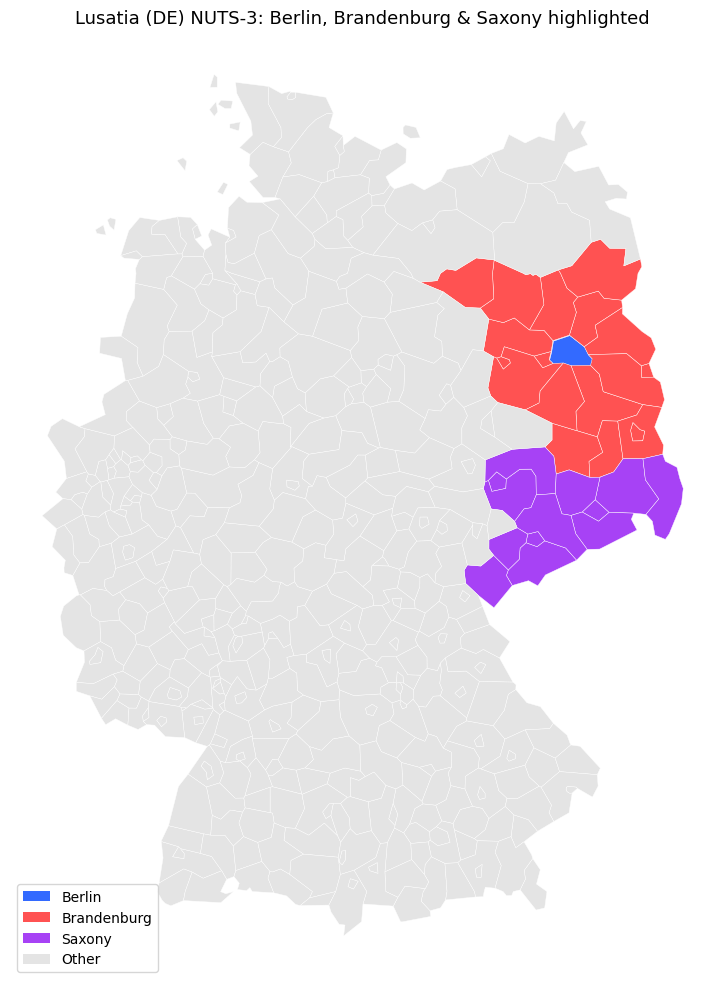

In [24]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(8, 10))
colors = {"Berlin": "#336aff", "Brandenburg": "#ff5252",
          "Saxony": "#a742f5", "Other": "#e0e0e0de", }
for group, color in colors.items():
    subset = de_nuts3[de_nuts3["region_group"] == group]
    subset.plot(ax=ax, color=color, edgecolor="white",
                linewidth=0.3, label=group)

ax.set_title("Lusatia (DE) NUTS-3: Berlin, Brandenburg & Saxony highlighted", fontsize=13)
ax.legend(
    handles=[Patch(facecolor=c, label=g) for g,c in colors.items()],
    loc="lower left", fontsize=10
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

NUTS-3 districts:

In [25]:
print(f"""
Berlin:      {(de_nuts3['region_group'] == 'Berlin').sum()}
Brandenburg: {(de_nuts3['region_group'] == 'Brandenburg').sum()}
Saxony:      {(de_nuts3['region_group'] == 'Saxony').sum()}
Total DE:    {len(de_nuts3)}
""")


Berlin:      1
Brandenburg: 18
Saxony:      13
Total DE:    401



## 5. Summary

Item|Value
----|-----
NUTS levels ingested | 0, 1, 2, 3
NUTS-3 features (EU) | 1,514
NUTS-3 features (DE) | 401
Classification year | 2021
Scale | 20M (1:20 million)
DuckDB spatial | WORKS (`ST_Area`, `ST_Transform`, `ST_Contains` verified)
Storage format | GeoParquet cache + DuckDB persistent tables
Hierarchy view | `nuts_hierarchy` joins all 4 levels
DuckDB <-> GeoPandas | WKB round-trip verified

### DuckDB schema

```
nuts0  (NUTS_ID, CNTR_CODE, NUTS_NAME, ..., geometry)
nuts1  (NUTS_ID, CNTR_CODE, NUTS_NAME, country_code, ..., geometry)
nuts2  (NUTS_ID, CNTR_CODE, NUTS_NAME, country_code, nuts1_code, ..., geometry)
nuts3  (NUTS_ID, CNTR_CODE, NUTS_NAME, country_code, nuts1_code, nuts2_code, ..., geometry)
nuts_hierarchy  (VIEW: nuts3_id → nuts2 → nuts1 → country, with attributes)
```

### Next steps

- **Step 2**: Data source evaluation notebooks (Regionalstatistik yields, DWD station mapping, CORINE, SoilGrids, ERA5-Land, etc.)
- Each source gets a dedicated section: fetch sample -> assess NUTS-3 coverage -> signal vs noise -> verdict

In [26]:
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
